In [1]:
# Project 3
# Intelligent College Examination Management & Analytics System

print("Project 3 Started Successfully! 🚀")

Project 3 Started Successfully! 🚀


In [2]:
import pandas as pd

data = {
    "Student_ID": [101, 102, 103, 104, 105],
    "Attendance": [85, 92, 76, 88, 95],
    "Internal_Marks": [78, 85, 65, 72, 90],
    "Previous_Score": [74, 88, 60, 70, 91],
    "Study_Hours": [5, 7, 3, 4, 8],
    "Exam_Score": [76, 89, 62, 71, 94]
}

df = pd.DataFrame(data)

df

,Student_ID,Attendance,Internal_Marks,Previous_Score,Study_Hours,Exam_Score
0,101,85,78,74,5,76
1,102,92,85,88,7,89
2,103,76,65,60,3,62
3,104,88,72,70,4,71
4,105,95,90,91,8,94


In [3]:
import pandas as pd
import numpy as np

np.random.seed(42)

n = 200

data = {
    "Student_ID": range(1001, 1001 + n),
    "Attendance": np.random.randint(60, 101, n),
    "Internal_Marks": np.random.randint(40, 96, n),
    "Previous_Score": np.random.randint(40, 96, n),
    "Study_Hours": np.random.randint(1, 11, n)
}

df = pd.DataFrame(data)

# Generate realistic exam scores
df["Exam_Score"] = (
    0.25 * df["Attendance"] +
    0.30 * df["Internal_Marks"] +
    0.25 * df["Previous_Score"] +
    2.0 * df["Study_Hours"] +
    np.random.normal(0, 5, n)
).clip(0, 100).round(1)

df.head(10)

,Student_ID,Attendance,Internal_Marks,Previous_Score,Study_Hours,Exam_Score
0,1001,98,50,54,3,60.0
1,1002,88,87,67,9,83.1
2,1003,74,55,73,1,63.3
3,1004,67,72,41,1,57.0
4,1005,80,48,71,4,55.8
5,1006,98,45,62,9,72.1
6,1007,78,55,61,6,65.1
7,1008,82,68,90,3,78.0
8,1009,70,42,64,1,52.4
9,1010,70,59,61,4,57.9


In [4]:
# Dataset information
print("Dataset Shape:", df.shape)

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistical Summary:")
df.describe()

Dataset Shape: (200, 6)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Student_ID      200 non-null    int64  
 1   Attendance      200 non-null    int64  
 2   Internal_Marks  200 non-null    int64  
 3   Previous_Score  200 non-null    int64  
 4   Study_Hours     200 non-null    int64  
 5   Exam_Score      200 non-null    float64
dtypes: float64(1), int64(5)
memory usage: 9.5 KB

Missing Values:
Student_ID        0
Attendance        0
Internal_Marks    0
Previous_Score    0
Study_Hours       0
Exam_Score        0
dtype: int64

Statistical Summary:


,Student_ID,Attendance,Internal_Marks,Previous_Score,Study_Hours,Exam_Score
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,1100.500000,80.050000,68.425000,68.810000,5.405000,69.006000
std,57.879185,12.279717,15.493048,15.993211,2.933257,10.557927
min,1001.000000,60.000000,40.000000,40.000000,1.000000,43.400000
25%,1050.750000,68.000000,57.000000,55.000000,3.000000,60.675000
50%,1100.500000,82.000000,69.000000,69.000000,5.000000,69.350000
75%,1150.250000,91.000000,81.000000,83.000000,8.000000,76.500000
max,1200.000000,100.000000,95.000000,95.000000,10.000000,98.200000


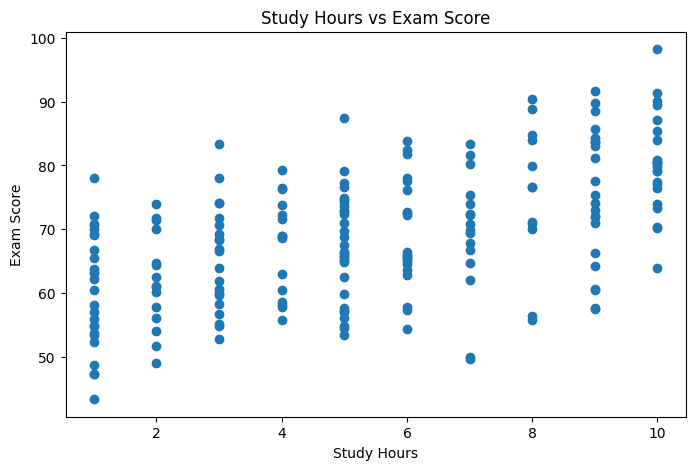

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(df["Study_Hours"], df["Exam_Score"])

plt.xlabel("Study Hours")
plt.ylabel("Exam Score")
plt.title("Study Hours vs Exam Score")

plt.show()

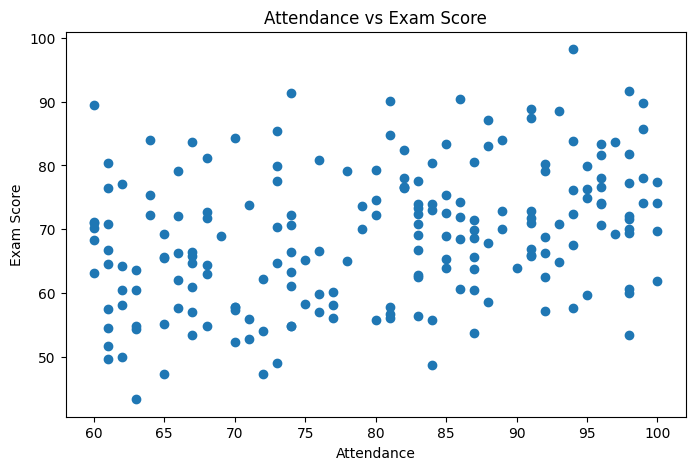

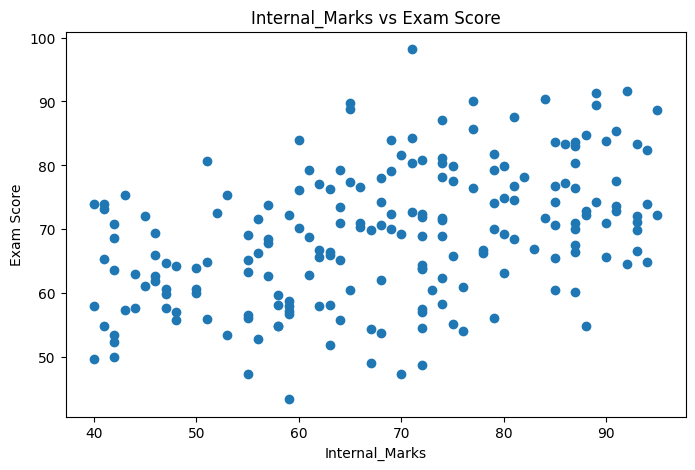

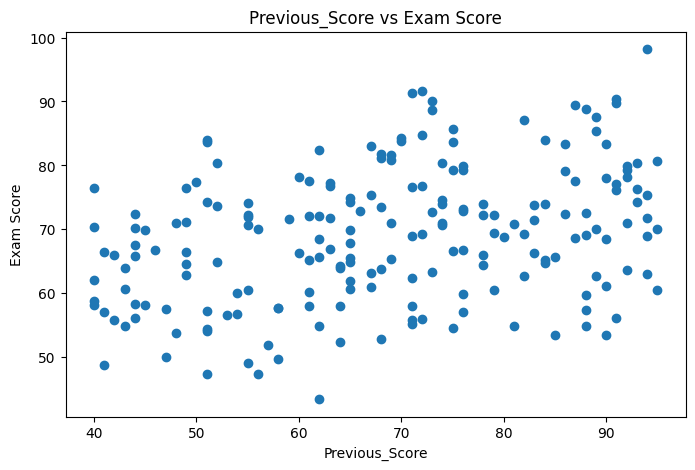

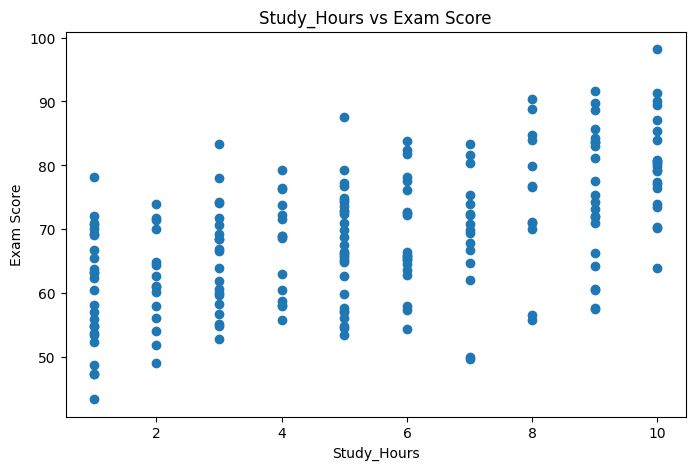

In [6]:
import matplotlib.pyplot as plt

features = ["Attendance", "Internal_Marks", "Previous_Score", "Study_Hours"]

for feature in features:
    plt.figure(figsize=(8, 5))
    plt.scatter(df[feature], df["Exam_Score"])
    plt.xlabel(feature)
    plt.ylabel("Exam Score")
    plt.title(f"{feature} vs Exam Score")
    plt.show()

In [7]:
print("Number of features:", len(features))
print("Features:", features)

Number of features: 4
Features: ['Attendance', 'Internal_Marks', 'Previous_Score', 'Study_Hours']


In [8]:
correlation = df.corr(numeric_only=True)

print("Correlation with Exam Score:")
print(correlation["Exam_Score"].sort_values(ascending=False))

Correlation with Exam Score:
Exam_Score        1.000000
Study_Hours       0.554372
Internal_Marks    0.438667
Previous_Score    0.345779
Attendance        0.338435
Student_ID        0.001284
Name: Exam_Score, dtype: float64


In [9]:
from sklearn.model_selection import train_test_split

# Input features
X = df[[
    "Attendance",
    "Internal_Marks",
    "Previous_Score",
    "Study_Hours"
]]

# Target variable
y = df["Exam_Score"]

# Split dataset into training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (160, 4)
Testing data: (40, 4)


In [10]:
from sklearn.linear_model import LinearRegression

# Create the model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

print("Linear Regression Model trained successfully! 🤖")

Linear Regression Model trained successfully! 🤖


In [11]:
# Make predictions on the test data
y_pred = model.predict(X_test)

# Show actual vs predicted scores
results = pd.DataFrame({
    "Actual_Score": y_test.values,
    "Predicted_Score": y_pred.round(2)
})

results.head(10)

,Actual_Score,Predicted_Score
0,68.6,63.91
1,56.7,57.49
2,77.1,77.05
3,81.8,77.84
4,66.9,70.01
5,70.2,64.05
6,72.3,71.36
7,77.4,77.40
8,64.2,63.74
9,57.7,61.97


In [12]:
from sklearn.metrics import mean_absolute_error, r2_score

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Linear Regression Evaluation")
print("----------------------------")
print(f"Mean Absolute Error: {mae:.2f}")
print(f"R² Score: {r2:.2f}")

Linear Regression Evaluation
----------------------------
Mean Absolute Error: 3.62
R² Score: 0.75


In [13]:
from sklearn.ensemble import RandomForestRegressor

# Create Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions
rf_pred = rf_model.predict(X_test)

print("Random Forest Model trained successfully! 🌲🤖")

Random Forest Model trained successfully! 🌲🤖


In [14]:
from sklearn.metrics import mean_absolute_error, r2_score

# Evaluate Random Forest
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest Evaluation")
print("------------------------")
print(f"Mean Absolute Error: {rf_mae:.2f}")
print(f"R² Score: {rf_r2:.2f}")

Random Forest Evaluation
------------------------
Mean Absolute Error: 4.35
R² Score: 0.69


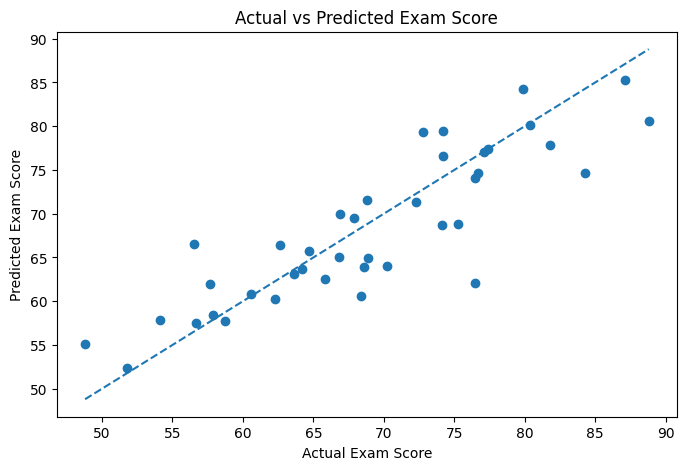

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Exam Score")
plt.ylabel("Predicted Exam Score")
plt.title("Actual vs Predicted Exam Score")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.show()

In [16]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficients = coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

print("Feature Impact on Exam Score")
print("---------------------------")
print(coefficients)

Feature Impact on Exam Score
---------------------------
          Feature  Coefficient
3     Study_Hours     2.019119
1  Internal_Marks     0.320573
0      Attendance     0.256017
2  Previous_Score     0.252022


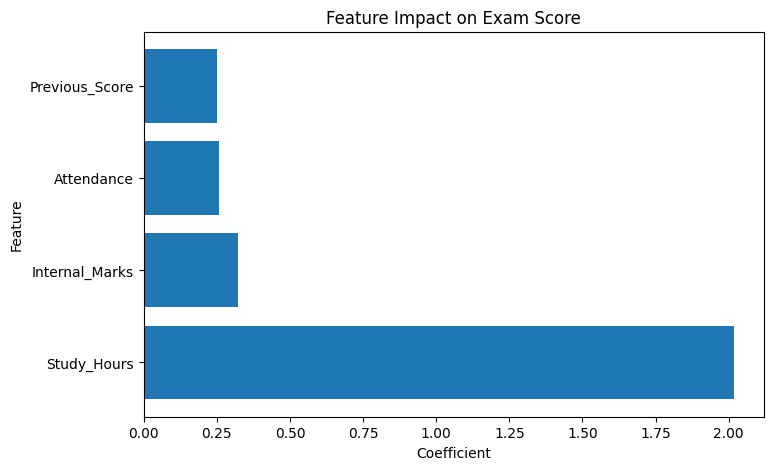

In [17]:
plt.figure(figsize=(8, 5))

plt.barh(
    coefficients["Feature"],
    coefficients["Coefficient"]
)

plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.title("Feature Impact on Exam Score")

plt.show()

In [18]:
# New Student Data

new_student = pd.DataFrame({
    "Attendance": [90],
    "Internal_Marks": [80],
    "Previous_Score": [75],
    "Study_Hours": [6]
})

predicted_score = model.predict(new_student)

print("Predicted Exam Score:", round(predicted_score[0], 2))

Predicted Exam Score: 77.88


In [19]:
score = predicted_score[0]

if score >= 85:
    performance = "Excellent"
elif score >= 70:
    performance = "Good"
elif score >= 50:
    performance = "Average"
else:
    performance = "Needs Improvement"

print("Predicted Exam Score:", round(score, 2))
print("Performance Level:", performance)

Predicted Exam Score: 77.88
Performance Level: Good


In [21]:
def predict_student_performance(attendance, internal_marks, previous_score, study_hours):

    student_data = pd.DataFrame({
        "Attendance": [attendance],
        "Internal_Marks": [internal_marks],
        "Previous_Score": [previous_score],
        "Study_Hours": [study_hours]
    })

    score = model.predict(student_data)[0]

    if score >= 85:
        performance = "Excellent"
    elif score >= 70:
        performance = "Good"
    elif score >= 50:
        performance = "Average"
    else:
        performance = "Needs Improvement"

    print("Predicted Exam Score:", round(score, 2))
    print("Performance Level:", performance)

In [22]:
predict_student_performance(
    attendance=90,
    internal_marks=80,
    previous_score=75,
    study_hours=6
)

Predicted Exam Score: 77.88
Performance Level: Good


In [23]:
def check_student_risk(score):

    if score < 50:
        risk = "High Risk"
    elif score < 70:
        risk = "Moderate Risk"
    else:
        risk = "Low Risk"

    print("Predicted Score:", round(score, 2))
    print("Risk Level:", risk)

In [24]:
check_student_risk(predicted_score[0])

Predicted Score: 77.88
Risk Level: Low Risk


In [25]:
def generate_student_report(attendance, internal_marks, previous_score, study_hours):

    student_data = pd.DataFrame({
        "Attendance": [attendance],
        "Internal_Marks": [internal_marks],
        "Previous_Score": [previous_score],
        "Study_Hours": [study_hours]
    })

    score = model.predict(student_data)[0]

    if score >= 85:
        performance = "Excellent"
    elif score >= 70:
        performance = "Good"
    elif score >= 50:
        performance = "Average"
    else:
        performance = "Needs Improvement"

    if score < 50:
        risk = "High Risk"
    elif score < 70:
        risk = "Moderate Risk"
    else:
        risk = "Low Risk"

    print("Student Performance Report")
    print("--------------------------")
    print("Attendance:", attendance)
    print("Internal Marks:", internal_marks)
    print("Previous Score:", previous_score)
    print("Study Hours:", study_hours)
    print("Predicted Exam Score:", round(score, 2))
    print("Performance Level:", performance)
    print("Risk Level:", risk)

In [26]:
generate_student_report(
    attendance=90,
    internal_marks=80,
    previous_score=75,
    study_hours=6
)

Student Performance Report
--------------------------
Attendance: 90
Internal Marks: 80
Previous Score: 75
Study Hours: 6
Predicted Exam Score: 77.88
Performance Level: Good
Risk Level: Low Risk


In [27]:
print("Overall Student Performance Analysis")
print("------------------------------------")

print("Total Students:", len(df))
print("Average Exam Score:", round(df["Exam_Score"].mean(), 2))
print("Highest Exam Score:", df["Exam_Score"].max())
print("Lowest Exam Score:", df["Exam_Score"].min())
print("Average Attendance:", round(df["Attendance"].mean(), 2))
print("Average Study Hours:", round(df["Study_Hours"].mean(), 2))

Overall Student Performance Analysis
------------------------------------
Total Students: 200
Average Exam Score: 69.01
Highest Exam Score: 98.2
Lowest Exam Score: 43.4
Average Attendance: 80.05
Average Study Hours: 5.4


In [28]:
def performance_category(score):

    if score >= 85:
        return "Excellent"
    elif score >= 70:
        return "Good"
    elif score >= 50:
        return "Average"
    else:
        return "Needs Improvement"


df["Performance_Level"] = df["Exam_Score"].apply(performance_category)

print("Student Performance Distribution")
print("-------------------------------")
print(df["Performance_Level"].value_counts())

Student Performance Distribution
-------------------------------
Performance_Level
Average              97
Good                 84
Excellent            13
Needs Improvement     6
Name: count, dtype: int64


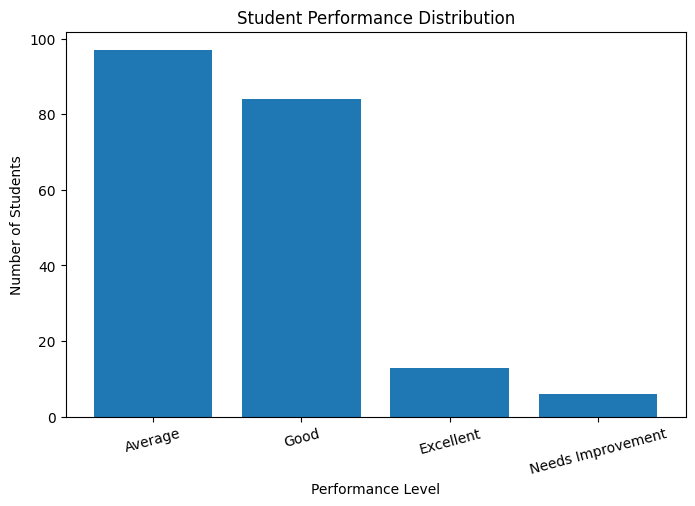

In [29]:
performance_counts = df["Performance_Level"].value_counts()

plt.figure(figsize=(8, 5))

plt.bar(
    performance_counts.index,
    performance_counts.values
)

plt.xlabel("Performance Level")
plt.ylabel("Number of Students")
plt.title("Student Performance Distribution")

plt.xticks(rotation=15)
plt.show()

In [30]:
def risk_category(score):

    if score < 50:
        return "High Risk"
    elif score < 70:
        return "Moderate Risk"
    else:
        return "Low Risk"


df["Risk_Level"] = df["Exam_Score"].apply(risk_category)

print("Student Risk Distribution")
print("-------------------------")
print(df["Risk_Level"].value_counts())

Student Risk Distribution
-------------------------
Risk_Level
Moderate Risk    97
Low Risk         97
High Risk         6
Name: count, dtype: int64


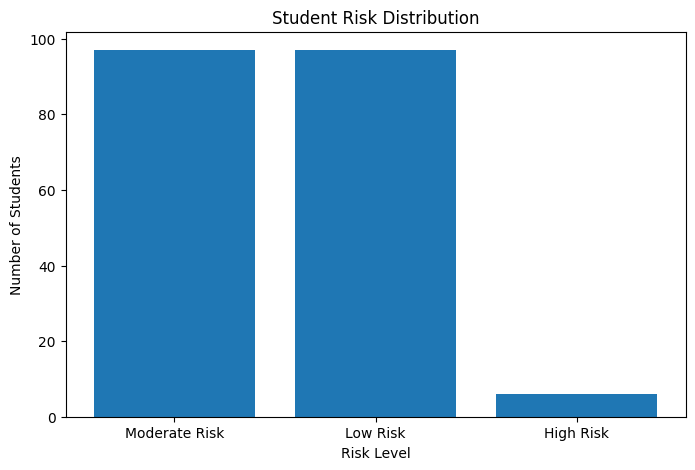

In [31]:
risk_counts = df["Risk_Level"].value_counts()

plt.figure(figsize=(8, 5))

plt.bar(
    risk_counts.index,
    risk_counts.values
)

plt.xlabel("Risk Level")
plt.ylabel("Number of Students")
plt.title("Student Risk Distribution")

plt.show()

In [32]:
at_risk_students = df[df["Risk_Level"] == "High Risk"]

print("High Risk Students")
print("------------------")
print(at_risk_students[
    [
        "Student_ID",
        "Attendance",
        "Internal_Marks",
        "Previous_Score",
        "Study_Hours",
        "Exam_Score",
        "Performance_Level",
        "Risk_Level"
    ]
])

High Risk Students
------------------
     Student_ID  Attendance  Internal_Marks  Previous_Score  Study_Hours  \
42         1043          61              40              58            7   
54         1055          65              55              51            1   
118        1119          73              67              55            2   
150        1151          84              72              41            1   
155        1156          72              70              56            1   
191        1192          63              59              62            1   

     Exam_Score  Performance_Level Risk_Level  
42         49.7  Needs Improvement  High Risk  
54         47.3  Needs Improvement  High Risk  
118        49.1  Needs Improvement  High Risk  
150        48.8  Needs Improvement  High Risk  
155        47.3  Needs Improvement  High Risk  
191        43.4  Needs Improvement  High Risk  


In [33]:
print("High Risk Student Analysis")
print("--------------------------")

print("Number of High Risk Students:", len(at_risk_students))
print(
    "Average Exam Score:",
    round(at_risk_students["Exam_Score"].mean(), 2)
)
print(
    "Average Attendance:",
    round(at_risk_students["Attendance"].mean(), 2)
)
print(
    "Average Study Hours:",
    round(at_risk_students["Study_Hours"].mean(), 2)
)

High Risk Student Analysis
--------------------------
Number of High Risk Students: 6
Average Exam Score: 47.6
Average Attendance: 69.67
Average Study Hours: 2.17


In [34]:
df.to_csv("student_exam_performance_analysis.csv", index=False)

print("Final dataset saved successfully! ✅")
print("File: student_exam_performance_analysis.csv")

Final dataset saved successfully! ✅
File: student_exam_performance_analysis.csv


In [35]:
model_comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [mae, rf_mae],
    "R2_Score": [r2, rf_r2]
})

print("Model Performance Comparison")
print("----------------------------")
print(model_comparison.round(2))

Model Performance Comparison
----------------------------
               Model   MAE  R2_Score
0  Linear Regression  3.62      0.75
1      Random Forest  4.35      0.69


In [36]:
import gradio as gr

def predict_exam_performance(attendance, internal_marks, previous_score, study_hours):

    student_data = pd.DataFrame({
        "Attendance": [attendance],
        "Internal_Marks": [internal_marks],
        "Previous_Score": [previous_score],
        "Study_Hours": [study_hours]
    })

    score = model.predict(student_data)[0]

    if score >= 85:
        performance = "Excellent"
    elif score >= 70:
        performance = "Good"
    elif score >= 50:
        performance = "Average"
    else:
        performance = "Needs Improvement"

    if score < 50:
        risk = "High Risk"
    elif score < 70:
        risk = "Moderate Risk"
    else:
        risk = "Low Risk"

    return round(score, 2), performance, risk


interface = gr.Interface(
    fn=predict_exam_performance,
    inputs=[
        gr.Slider(60, 100, value=80, step=1, label="Attendance (%)"),
        gr.Slider(40, 95, value=70, step=1, label="Internal Marks"),
        gr.Slider(40, 95, value=70, step=1, label="Previous Score"),
        gr.Slider(1, 10, value=5, step=1, label="Study Hours per Day")
    ],
    outputs=[
        gr.Number(label="Predicted Exam Score"),
        gr.Textbox(label="Performance Level"),
        gr.Textbox(label="Risk Level")
    ],
    title="Intelligent College Examination Management & Analytics System",
    description="Predict student exam performance using attendance, internal marks, previous score, and study hours."
)

interface.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://35ab0a7cb69d832d34.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
